In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

import joblib
import json
import warnings
warnings.filterwarnings("ignore")

In [14]:
df = pd.read_csv("../data/credit_risk_dataset.csv")

In [15]:
df.shape

(32581, 12)

In [16]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [17]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

person_emp_length  ve loan_int_rate  değerlerinde eksik evri olduğu için temizliyoruz

In [18]:
def data_cleaning(df_real):
    df = df_real.copy()

    # eda da bulduğumuz outlier değerleri çıkardık 
    df = df[df["person_age"] <= 90]
    df = df[df["person_emp_length"] <= 60]


    # eksik veriler person_emp_length ve loan_int_rate var medyan değerleri ile dolduruyoruz
    df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())
    df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())

    return df.reset_index(drop=True)


df_clean = data_cleaning(df)
print("\nTemizlik sonrası boyut:", df_clean.shape)


Temizlik sonrası boyut: (31678, 12)


In [19]:
def feature_engineering(df_clean):
    df = df_clean.copy()
    # credit_history_ratio = credit lenght / customer age
    df["credit_history_ratio"] = df["cb_person_cred_hist_length"]/ df["person_age"]

    # emp_length_ratio employment time / customer age
    df["emp_length_ratio"] = df["person_emp_length"] / df["person_age"]

    # loan_emp_length  : kredi mikttarı / çalışma zamanı
    df["loan_emp_length"] = df["loan_amnt"]/ (df["person_emp_length"] + 1)  

    # income_to_loan = income / loan miktarı  +1 loan = 0 durumu için 
    df["income_to_loan"] = df["person_income"] /(df["loan_amnt"]+1)

    #  cb_person_default_on_file değişkenini 0-1 yapıyoruz 
    df["default"] = (df["cb_person_default_on_file"] == "Y").astype(int)

    # age_group: Yaşı
    df["age_group"] = pd.cut(
        df["person_age"],
        bins=[0, 25, 35, 50, 100],
        labels=["18-25", "26-35", "36-50", "50+"]
    )

    return df


df = feature_engineering(df_clean)
print("Yeni feature'lar eklendi. Toplam kolon sayısı:", df.shape[1])
df[["credit_history_ratio", "emp_length_ratio", "loan_emp_length",
       "income_to_loan", "default", "age_group"]].head()

Yeni feature'lar eklendi. Toplam kolon sayısı: 18


,credit_history_ratio,emp_length_ratio,loan_emp_length,income_to_loan,default,age_group
0,0.095238,0.238095,166.666667,9.590410,0,18-25
1,0.120000,0.040000,2750.000000,1.745137,0,18-25
2,0.086957,0.173913,7000.000000,1.871375,0,18-25
3,0.166667,0.333333,3888.888889,1.554241,1,18-25
4,0.095238,0.095238,833.333333,3.958417,0,18-25


In [20]:
numeric_features = [
    "person_age", "person_income", "person_emp_length",
    "loan_amnt", "loan_int_rate", "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_history_ratio", "emp_length_ratio",
    "loan_emp_length", "income_to_loan", "default",
]

categorical_features = [
    "person_home_ownership", "loan_intent", "loan_grade",
    "cb_person_default_on_file", "age_group",
]


X = df[numeric_features + categorical_features]
y = df["loan_status"]


## Train-test split 

In [21]:
X_train , X_test , y_train, y_test = train_test_split(X , y, test_size=0.2,random_state = 42 , stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (25342, 17)  Test: (6336, 17)


## Preprocessing 

In [22]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat" , OneHotEncoder(handle_unknown="ignore", drop="first"),categorical_features),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


## SMOTE

In [23]:
smote = SMOTE(random_state= 42)
X_train_sm , y_train_sm = smote.fit_resample(X_train_processed,y_train)
print("SMOTE öncesi:", y_train.value_counts().to_dict())
print("SMOTE sonrası:", pd.Series(y_train_sm).value_counts().to_dict())

SMOTE öncesi: {0: 19882, 1: 5460}
SMOTE sonrası: {0: 19882, 1: 19882}


## Model eğitimi

In [24]:
results = {}
roc_data = {}

## Logistic Rgression

In [25]:
log_reg = LogisticRegression(max_iter=1000, random_state=43)
log_reg.fit(X_train_sm,y_train_sm)

y_proba = log_reg.predict_proba(X_test_processed)[:,1]

y_pred = (y_proba >=0.5).astype(int)

auc = roc_auc_score(y_test,y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

results["Logistic Regression"] = {"model": log_reg, "auc": auc, "y_proba": y_proba}
roc_data["Logistic Regression"] = (fpr, tpr, auc)

print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Ödendi", "Default"]))

AUC: 0.8765
              precision    recall  f1-score   support

      Ödendi       0.93      0.83      0.88      4971
     Default       0.55      0.78      0.64      1365

    accuracy                           0.82      6336
   macro avg       0.74      0.80      0.76      6336
weighted avg       0.85      0.82      0.83      6336



## KNN

In [26]:
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_sm , y_train_sm)

y_proba = knn.predict_proba(X_test_processed)[:,1]
y_pred = (y_proba >=0.5).astype(int)

auc = roc_auc_score(y_test , y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

results["KNN"] = {"model": knn, "auc": auc, "y_proba": y_proba}
roc_data["KNN"] = (fpr, tpr, auc)

print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Ödendi", "Default"]))


AUC: 0.8701
              precision    recall  f1-score   support

      Ödendi       0.93      0.80      0.86      4971
     Default       0.52      0.80      0.63      1365

    accuracy                           0.80      6336
   macro avg       0.73      0.80      0.75      6336
weighted avg       0.85      0.80      0.81      6336



## Random Forest

In [27]:
random_forest = RandomForestClassifier(n_estimators = 300, max_depth=10,class_weight="balanced", random_state=42 , n_jobs=-1)

random_forest.fit(X_train_processed,y_train)

y_proba = random_forest.predict_proba(X_test_processed)[:,1]

y_pred = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)
results["Random Forest"] = {"model": random_forest, "auc": auc, "y_proba": y_proba}
roc_data["Random Forest"] = (fpr, tpr, auc)

print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Ödendi", "Default"]))


AUC: 0.9302
              precision    recall  f1-score   support

      Ödendi       0.94      0.96      0.95      4971
     Default       0.82      0.76      0.79      1365

    accuracy                           0.91      6336
   macro avg       0.88      0.86      0.87      6336
weighted avg       0.91      0.91      0.91      6336



## XGBoost

In [28]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(n_estimators=300,max_depth = 5 , learning_rate = 0.05, scale_pos_weight= scale_pos_weight,eval_metric = "logloss", random_state = 42 , n_jobs=-1)

xgb.fit(X_train_processed,y_train)

y_proba = xgb.predict_proba(X_test_processed)[:,1]
y_pred = (y_proba >= 0.5).astype(int)


auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

results["XGBoost"] = {"model": xgb, "auc": auc, "y_proba": y_proba}
roc_data["XGBoost"] = (fpr, tpr, auc)

print(f"AUC: {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=["Ödendi", "Default"]))

AUC: 0.9457
              precision    recall  f1-score   support

      Ödendi       0.94      0.95      0.94      4971
     Default       0.80      0.79      0.80      1365

    accuracy                           0.91      6336
   macro avg       0.87      0.87      0.87      6336
weighted avg       0.91      0.91      0.91      6336



In [29]:
best_name = max(results, key=lambda k: results[k]["auc"])
best_model = results[best_name]["model"]
print(f"En iyi model: {best_name} (AUC={results[best_name]['auc']:.4f})")

En iyi model: XGBoost (AUC=0.9457)


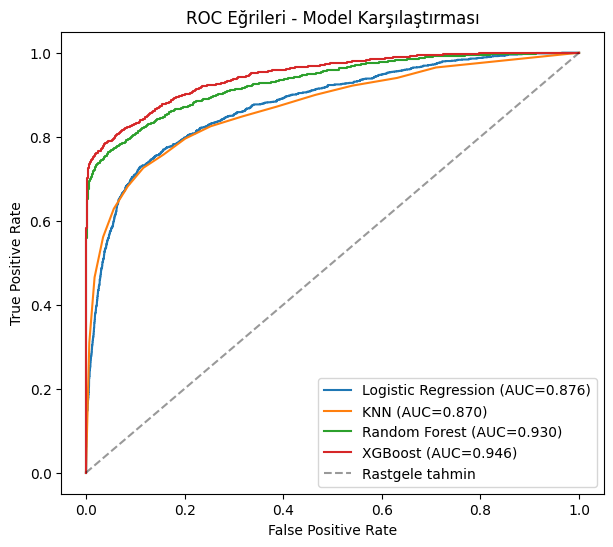

In [30]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Rastgele tahmin")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Eğrileri - Model Karşılaştırması")
plt.legend()
plt.show()

In [31]:
FN_COST = 5   # temerrüde düşecek birine kredi vermenin maliyeti
FP_COST = 1   # iyi müşteriye kredi vermemenin fırsat maliyeti

y_proba_best = results[best_name]["y_proba"]

best_threshold, best_cost = 0.5, float("inf")
for t in np.arange(0.05, 0.95, 0.01):
    y_pred_t = (y_proba_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    cost = FN_COST * fn + FP_COST * fp
    if cost < best_cost:
        best_cost = cost
        best_threshold = t

print(f"Optimum threshold: {best_threshold:.2f}")

y_pred_final = (y_proba_best >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_final, target_names=["Ödendi", "Default"]))

Optimum threshold: 0.34
              precision    recall  f1-score   support

      Ödendi       0.96      0.85      0.90      4971
     Default       0.61      0.88      0.72      1365

    accuracy                           0.85      6336
   macro avg       0.79      0.86      0.81      6336
weighted avg       0.89      0.85      0.86      6336



In [32]:
joblib.dump(best_model, "../models/best_model.joblib")
joblib.dump(preprocessor, "../models/preprocessor.joblib")

metadata = {
    "best_model_name": best_name,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "threshold": float(round(best_threshold, 2)),
    "auc_scores": {k: v["auc"] for k, v in results.items()},
}

with open("../models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Kaydedildi: models/best_model.joblib, preprocessor.joblib, metadata.json")

Kaydedildi: models/best_model.joblib, preprocessor.joblib, metadata.json


## Cost-Based Threshold Seçimi

In [33]:
FN_COST = 5   # temerrüde düşecek birine kredi vermenin maliyeti
FP_COST = 1   # iyi müşteriye kredi vermemenin fırsat maliyeti

y_proba_best = results[best_name]["y_proba"]

best_threshold, best_cost = 0.5, float("inf")
for t in np.arange(0.05, 0.95, 0.01):
    y_pred_t = (y_proba_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    cost = FN_COST * fn + FP_COST * fp
    if cost < best_cost:
        best_cost = cost
        best_threshold = t

print(f"En iyi model: {best_name}")
print(f"Optimum threshold: {best_threshold:.2f}")

y_pred_final = (y_proba_best >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_final, target_names=["Ödendi", "Default"]))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print(f"\nConfusion Matrix @ threshold={best_threshold:.2f}")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

En iyi model: XGBoost
Optimum threshold: 0.34
              precision    recall  f1-score   support

      Ödendi       0.96      0.85      0.90      4971
     Default       0.61      0.88      0.72      1365

    accuracy                           0.85      6336
   macro avg       0.79      0.86      0.81      6336
weighted avg       0.89      0.85      0.86      6336


Confusion Matrix @ threshold=0.34
TN=4207  FP=764  FN=170  TP=1195


## Feature Importance

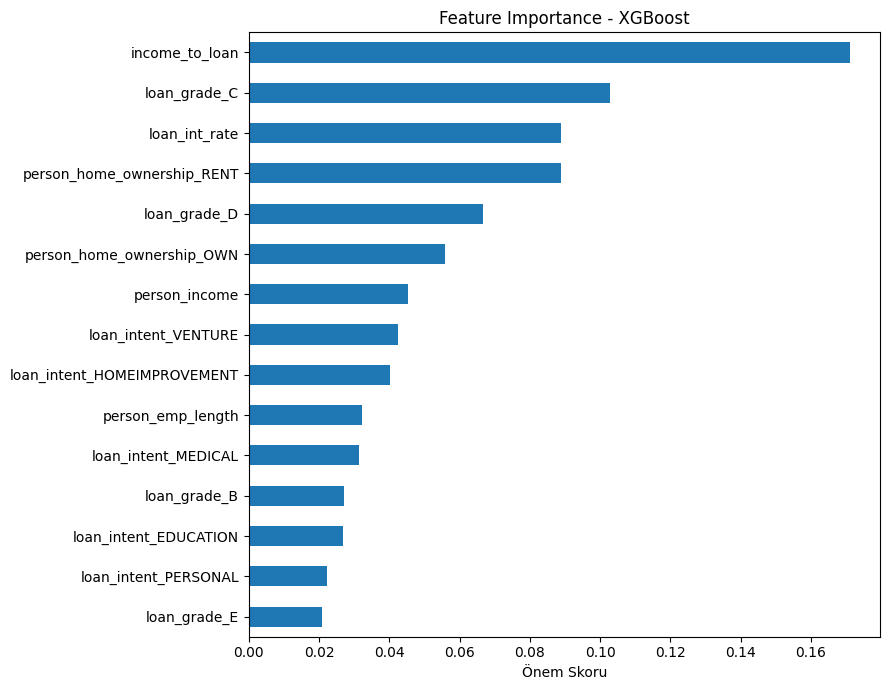

income_to_loan                 0.171162
loan_grade_C                   0.102935
loan_int_rate                  0.088920
person_home_ownership_RENT     0.088771
loan_grade_D                   0.066691
person_home_ownership_OWN      0.055746
person_income                  0.045209
loan_intent_VENTURE            0.042512
loan_intent_HOMEIMPROVEMENT    0.040229
person_emp_length              0.032321
loan_intent_MEDICAL            0.031354
loan_grade_B                   0.027195
loan_intent_EDUCATION          0.026694
loan_intent_PERSONAL           0.022168
loan_grade_E                   0.020718
dtype: float32


In [34]:
cat_feature_names = list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
all_feature_names = numeric_features + cat_feature_names

importances = pd.Series(best_model.feature_importances_, index=all_feature_names)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(9, 7))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title(f"Feature Importance - {best_name}")
plt.xlabel("Önem Skoru")
plt.tight_layout()
plt.show()

print(importances.head(15))

In [35]:
metadata = {
    "best_model_name": best_name,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "threshold": float(round(best_threshold, 2)),
    "auc_scores": {k: v["auc"] for k, v in results.items()},
}
with open("../models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("metadata.json güncellendi.")

metadata.json güncellendi.
